## Feature Engineering

In [1]:
# path setup
import sys
import os

#add project root to python path
project_root=os.path.abspath(os.path.join(os.getcwd(),'..'))
sys.path.append(project_root)
print(f"Project root: {project_root} ")

Project root: c:\Users\aryap\Desktop\predictive_maintenance 


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize']=(10,5)


In [3]:
#load data from MySQL
from database.db_load import get_data_from_mysql
df=get_data_from_mysql()
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")


⚙️  Retrieving data from MySQL...
✅ Data retrieved successfully — Shape: (10000, 14)

📋 First 3 rows:
   id product_id type  air_temperature  process_temperature  rotational_speed  \
0   1     M14860    M            298.1                308.6              1551   
1   2     L47181    L            298.2                308.7              1408   
2   3     L47182    L            298.1                308.5              1498   

   torque  tool_wear  machine_failure  twf  hdf  pwf  osf  rnf  
0    42.8          0                0    0    0    0    0    0  
1    46.3          3                0    0    0    0    0    0  
2    49.4          5                0    0    0    0    0    0  

📋 Data types:
id                       int64
product_id              object
type                    object
air_temperature        float64
process_temperature    float64
rotational_speed         int64
torque                 float64
tool_wear                int64
machine_failure          int64
twf               

Snapshot of Raw Data

In [4]:
#keep copy of raw data untouched
df_raw=df.copy()

print(f"Shape: {df.shape}")
print(f"Shape: {df_raw.shape}")

Shape: (10000, 14)
Shape: (10000, 14)


Engineering 3 New Features

In [5]:
# feature 1: Temp_Diff = Process Temperature - Air Temperature
# captures hdf trigger condition
# hdf fires when this value drops below 8.6k

df['temp_diff']=df['process_temperature']-df['air_temperature']

print("temp_diff engineered")
print(f" Min : {df['temp_diff'].min():.3f}K")
print(f" Max : {df['temp_diff'].max():.3f}K")
print(f" Mean : {df['temp_diff'].mean():.3f}K")
print(f" Values below HDF threshold (8.6K): {(df['temp_diff']<8.6).sum()}")


temp_diff engineered
 Min : 7.600K
 Max : 12.100K
 Mean : 10.001K
 Values below HDF threshold (8.6K): 720


In [6]:
#feature 2: Power(watts)= torque * angular velocity
# angular velocity= rpm* (2pi/60)
# pwf fires when Power<3500 or >9000W

df['power']=df['torque']*(df['rotational_speed']*(2*np.pi/60))

print("power engineered")
print(f" Min : {df['power'].min():.2f} W")
print(f" Max : {df['power'].max():.2f} W")
print(f" Mean : {df['power'].mean():.2f} W")
print(f" Values below 3500W (PWF low risk) : {(df['power']<3500).sum()}")
print(f" Values above 9000W (PWF high risk) : {(df['power']>9000).sum()}")


power engineered
 Min : 1148.44 W
 Max : 10469.92 W
 Mean : 6279.74 W
 Values below 3500W (PWF low risk) : 31
 Values above 9000W (PWF high risk) : 64


In [7]:
# feature 3: Tool_Wear_Torque = Tool Wear * Torque
# OSF fires when this exceeds:
# 11,000 for L-type, 12,000 for M-type, 13,000 for H-type
df['tool_wear_torque']=df['tool_wear']*df['torque']

print("tool_wear_torque engineered")
print(f" Min : {df['tool_wear_torque'].min():.2f}")
print(f" Max : {df['tool_wear_torque'].max():.2f}")
print(f" Mean : {df['tool_wear_torque'].mean():.2f}")

#check how many records breach osf thresholds per type
for ptype,threshold in [('L',11000),('M',12000),('H',13000)]:
    breach=df[
        (df['type']==ptype) &
        (df['tool_wear_torque']>threshold)
    ].shape[0]
    print(f" {ptype}- type breaching OSF threshold ({threshold}): {breach} records")

tool_wear_torque engineered
 Min : 0.00
 Max : 16497.00
 Mean : 4314.66
 L- type breaching OSF threshold (11000): 87 records
 M- type breaching OSF threshold (12000): 9 records
 H- type breaching OSF threshold (13000): 2 records


Verification of all 3 features together

In [8]:
print("Engineered Features- Summary")

engineered = ['temp_diff', 'power', 'tool_wear_torque']

for feat in engineered:
    print(f"\n{feat}:")
    print(f"  Min    : {df[feat].min():.3f}")
    print(f"  Max    : {df[feat].max():.3f}")
    print(f"  Mean   : {df[feat].mean():.3f}")
    print(f"  Nulls  : {df[feat].isnull().sum()}")

print("\nAll 3 engineered features verified - no nulls")
print(f"   DataFrame shape now: {df.shape}")

Engineered Features- Summary

temp_diff:
  Min    : 7.600
  Max    : 12.100
  Mean   : 10.001
  Nulls  : 0

power:
  Min    : 1148.441
  Max    : 10469.923
  Mean   : 6279.745
  Nulls  : 0

tool_wear_torque:
  Min    : 0.000
  Max    : 16497.000
  Mean   : 4314.665
  Nulls  : 0

All 3 engineered features verified - no nulls
   DataFrame shape now: (10000, 17)


Visualize engineered features vs failure

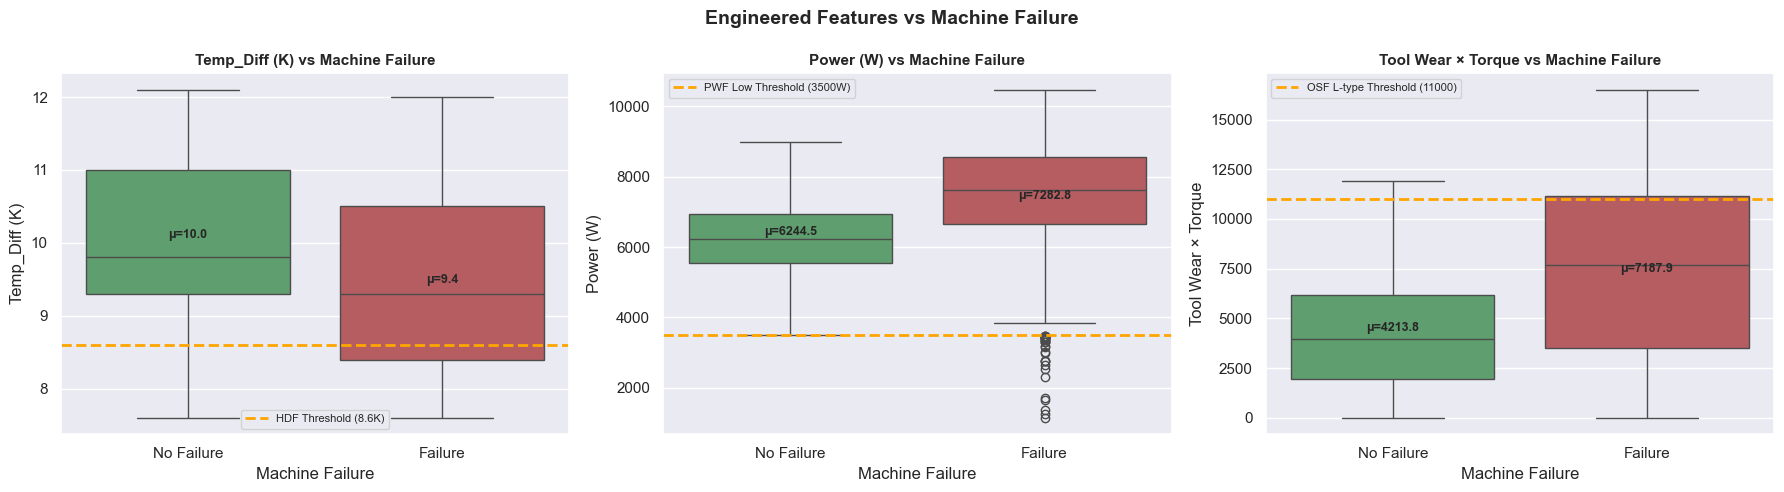

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

engineered_info = [
    ('temp_diff',        'Temp_Diff (K)',         8.6,   'HDF Threshold (8.6K)'),
    ('power',            'Power (W)',              3500,  'PWF Low Threshold (3500W)'),
    ('tool_wear_torque', 'Tool Wear × Torque',     11000, 'OSF L-type Threshold (11000)'),
]

for i, (feat, label, threshold, thresh_label) in enumerate(engineered_info):
    sns.boxplot(
        data    = df,
        x       = 'machine_failure',
        y       = feat,
        palette = ['#55A868', '#C44E52'],
        ax      = axes[i]
    )

    # Draw threshold line
    axes[i].axhline(
        y         = threshold,
        color     = 'orange',
        linestyle = '--',
        linewidth = 2,
        label     = thresh_label
    )

    # Annotate means
    for failure_val in [0, 1]:
        mean_val = df[df['machine_failure'] == failure_val][feat].mean()
        axes[i].text(
            failure_val, mean_val,
            f'μ={mean_val:.1f}',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold'
        )

    axes[i].set_title(f'{label} vs Machine Failure',
                      fontsize=11, fontweight='bold')
    axes[i].set_xticklabels(['No Failure', 'Failure'])
    axes[i].set_xlabel('Machine Failure')
    axes[i].set_ylabel(label)
    axes[i].legend(fontsize=8)

plt.suptitle('Engineered Features vs Machine Failure',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/engineered_features_vs_failure.png', dpi=150, bbox_inches='tight')
plt.show()


## Encode Product Type

Encode Type column

In [10]:
# encode product type
# L-0, M-1, H-2
# Ordinal encoding makes sense here because L<M<H represents increasing quality grade
# which directly maps to increasing OSF thresholds
# (11000<12000<13000)
type_mapping={'L':0,'M':1,'H':2}

df['type_encoded']=df['type'].map(type_mapping)

print("type_encoded engineered")
print(f"\n Mapping applied: {type_mapping}")
print(f"\n Value counts: ")
print(df['type_encoded'].value_counts().sort_index())
print(f"\n Nulls: {df['type_encoded'].isnull().sum()}")


type_encoded engineered

 Mapping applied: {'L': 0, 'M': 1, 'H': 2}

 Value counts: 
type_encoded
0    6000
1    2997
2    1003
Name: count, dtype: int64

 Nulls: 0


Verify encoding is correct

In [11]:
# confirm mapping is correct
print("Encoding spot check: ")
print(f"{'Original':<12} {'Encoded':<10} {'Count':<10}")

for original, encoded in type_mapping.items():
    count = (df['type_encoded'] == encoded).sum()
    print(f"{original:<12} {encoded:<10} {count:<10}")

# Confirm no original type values were missed
unmapped = df['type_encoded'].isnull().sum()
print(f"\nUnmapped values: {unmapped}")
print("All type values successfully encoded" if unmapped == 0 
      else "Some values failed to map — check type column")

Encoding spot check: 
Original     Encoded    Count     
L            0          6000      
M            1          2997      
H            2          1003      

Unmapped values: 0
All type values successfully encoded


BUILD RUL TARGET COLUMN

In [12]:
RUL_CEILING=240 # tool wear failure threshold (max tool wear before failure)

#compute RUL from tool wear
df['rul']=RUL_CEILING-df['tool_wear']

#overridden record- where machine already failed- RUL=0
df.loc[df['machine_failure']==1,'rul']=0

# safety clip: ensure no negative RUL values
df['rul']=df['rul'].clip(lower=0)

print(" RUL column engineered")
print(f"\n RUL Ceiling used: {RUL_CEILING} minutes")
print(f" Min RUL : {df['rul'].min()}")
print(f" Max RUL : {df['rul'].max()}")
print(f" Mean RUL : {df['rul'].mean():.2f}")
print(f" Median RUL : {df['rul'].median():.2f}")
print(f"\n   Records with RUL = 0  : {(df['rul'] == 0).sum()}")
print(f"   Records with RUL > 0  : {(df['rul'] > 0).sum()}")

 RUL column engineered

 RUL Ceiling used: 240 minutes
 Min RUL : 0
 Max RUL : 240
 Mean RUL : 128.79
 Median RUL : 130.00

   Records with RUL = 0  : 349
   Records with RUL > 0  : 9651


Visualize RUL distribution

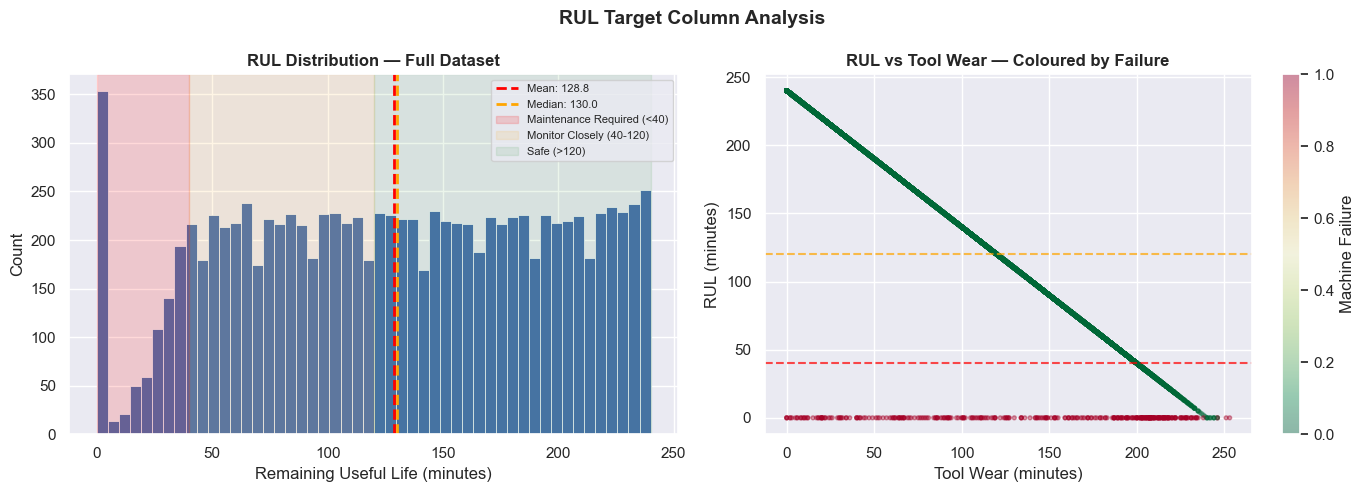

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full RUL distribution
axes[0].hist(
    df['rul'],
    bins      = 50,
    color     = '#4C72B0',
    edgecolor = 'white',
    linewidth = 0.5
)
axes[0].axvline(df['rul'].mean(),   color='red',    linestyle='--',
                linewidth=2, label=f"Mean: {df['rul'].mean():.1f}")
axes[0].axvline(df['rul'].median(), color='orange', linestyle='--',
                linewidth=2, label=f"Median: {df['rul'].median():.1f}")

# Mark the critical zones
axes[0].axvspan(0,   40,  alpha=0.15, color='red',    label='Maintenance Required (<40)')
axes[0].axvspan(40,  120, alpha=0.10, color='orange', label='Monitor Closely (40-120)')
axes[0].axvspan(120, 240, alpha=0.08, color='green',  label='Safe (>120)')

axes[0].set_title('RUL Distribution — Full Dataset',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Remaining Useful Life (minutes)')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)

#RUL vs Tool Wear scatter
scatter = axes[1].scatter(
    df['tool_wear'],
    df['rul'],
    c      = df['machine_failure'],
    cmap   = 'RdYlGn_r',
    alpha  = 0.4,
    s      = 8
)

axes[1].set_title('RUL vs Tool Wear — Coloured by Failure',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tool Wear (minutes)')
axes[1].set_ylabel('RUL (minutes)')

plt.colorbar(scatter, ax=axes[1], label='Machine Failure')

# Draw the RUL zones
axes[1].axhline(y=40,  color='red',    linestyle='--', linewidth=1.5, alpha=0.7)
axes[1].axhline(y=120, color='orange', linestyle='--', linewidth=1.5, alpha=0.7)

plt.suptitle('RUL Target Column Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/rul_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


RUL zone breakdown

In [14]:
# Define business recommendation zones
maintenance_required = (df['rul'] < 40).sum()
monitor_closely      = ((df['rul'] >= 40)  & (df['rul'] < 120)).sum()
safe                 = (df['rul'] >= 120).sum()

print("RUL Business Zone Breakdown:")

print(f"  🔴 Maintenance Required (RUL < 40)    : "
      f"{maintenance_required:>5} records "
      f"({maintenance_required/len(df)*100:.2f}%)")
print(f"  🟡 Monitor Closely (40 ≤ RUL < 120)  : "
      f"{monitor_closely:>5} records "
      f"({monitor_closely/len(df)*100:.2f}%)")
print(f"  🟢 Safe (RUL ≥ 120)                  : "
      f"{safe:>5} records "
      f"({safe/len(df)*100:.2f}%)")

print(f"  Total                                 : {len(df):>5} records")

RUL Business Zone Breakdown:
  🔴 Maintenance Required (RUL < 40)    :   983 records (9.83%)
  🟡 Monitor Closely (40 ≤ RUL < 120)  :  3557 records (35.57%)
  🟢 Safe (RUL ≥ 120)                  :  5460 records (54.60%)
  Total                                 : 10000 records


In [15]:
df.head()

,id,product_id,type,air_temperature,process_temperature,rotational_speed,torque,tool_wear,machine_failure,twf,hdf,pwf,osf,rnf,temp_diff,power,tool_wear_torque,type_encoded,rul
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,6951.590560,0.0,1,240
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,6826.722724,138.9,0,237
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,7749.387543,247.0,0,235
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,5927.504659,276.5,0,233
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,5897.816608,360.0,0,231


## Building Failure_Mode target column

In [16]:
# priority order based on frequency from EDA:
# HDF>OSF>PWF>TWF>RNF
def assign_failure_mode(row):
    # assigns a single failure mode label per record

    if row['hdf']==1: return 'HDF'
    elif row['osf']==1: return 'OSF'
    elif row['pwf']==1: return 'PWF'
    elif row['twf']==1: return 'TWF'
    elif row['rnf']==1: return 'RNF'
    else : return 'No Failure'

df['failure_mode'] = df.apply(assign_failure_mode, axis=1)
print("failure_mode column engineered")
print(f"\n   Value counts:")
print(df['failure_mode'].value_counts())
print(f"\n   Unique classes: {df['failure_mode'].nunique()}")


failure_mode column engineered

   Value counts:
failure_mode
No Failure    9652
HDF            115
OSF             92
PWF             80
TWF             43
RNF             18
Name: count, dtype: int64

   Unique classes: 6


Encode failure_mode as numeric

In [17]:
# models need numbers not strings
failure_mode_mapping={
    'No Failure' : 0,
    'HDF' : 1,
    'OSF' : 2,
    'PWF' : 3,
    'TWF' : 4,
    'RNF' : 5,
}

df['failure_mode_encoded'] = df['failure_mode'].map(failure_mode_mapping)
print("failure_mode_encoded engineered")
print(f"\n Mapping: {failure_mode_mapping}")
print(f"\n Value counts (encoded): ")
print(df['failure_mode_encoded'].value_counts().sort_index())
print(f"\n Nulls: {df['failure_mode_encoded'].isnull().sum()}")

failure_mode_encoded engineered

 Mapping: {'No Failure': 0, 'HDF': 1, 'OSF': 2, 'PWF': 3, 'TWF': 4, 'RNF': 5}

 Value counts (encoded): 
failure_mode_encoded
0    9652
1     115
2      92
3      80
4      43
5      18
Name: count, dtype: int64

 Nulls: 0


Verify priority rule on simultaneous failures

In [18]:
# confirm priority rule was applied correctly
simultaneous=df_raw[df_raw[['twf','hdf','pwf','osf','rnf']].sum(axis=1)>1]

print(f"Simultaneous Failure Records: {len(simultaneous)}")

print(f"{'ID':<6} {'TWF':<6} {'HDF':<6} {'PWF':<6} {'OSF':<6} {'RNF':<6} {'Assigned Mode':<15} ")

for idx in simultaneous.index:
    row=df_raw.loc[idx]
    assigned=df.loc[idx,'failure_mode']
    print(
        f"{int(row['id']):<6} "
        f"{int(row['twf']):<6} "
        f"{int(row['hdf']):<6} "
        f"{int(row['pwf']):<6} "
        f"{int(row['osf']):<6} "
        f"{int(row['rnf']):<6} "
        f"{assigned:<15}"
    )

print("Priority rule verified for all simultaneous failure records")


Simultaneous Failure Records: 24
ID     TWF    HDF    PWF    OSF    RNF    Assigned Mode   
70     0      0      1      1      0      OSF            
1325   0      0      1      1      0      OSF            
1497   0      0      1      1      0      OSF            
3612   1      0      0      0      1      TWF            
3855   0      0      1      1      0      OSF            
3944   0      0      1      1      0      OSF            
4255   0      1      1      0      0      HDF            
4343   0      1      1      0      0      HDF            
4371   0      1      0      1      0      HDF            
4384   0      1      0      1      0      HDF            
4418   0      1      1      0      0      HDF            
4463   0      1      0      1      0      HDF            
4643   0      1      0      1      0      HDF            
4644   0      1      0      1      0      HDF            
4730   0      1      0      1      0      HDF            
5395   0      0      1      1      0  

Visualize failure mode distribution

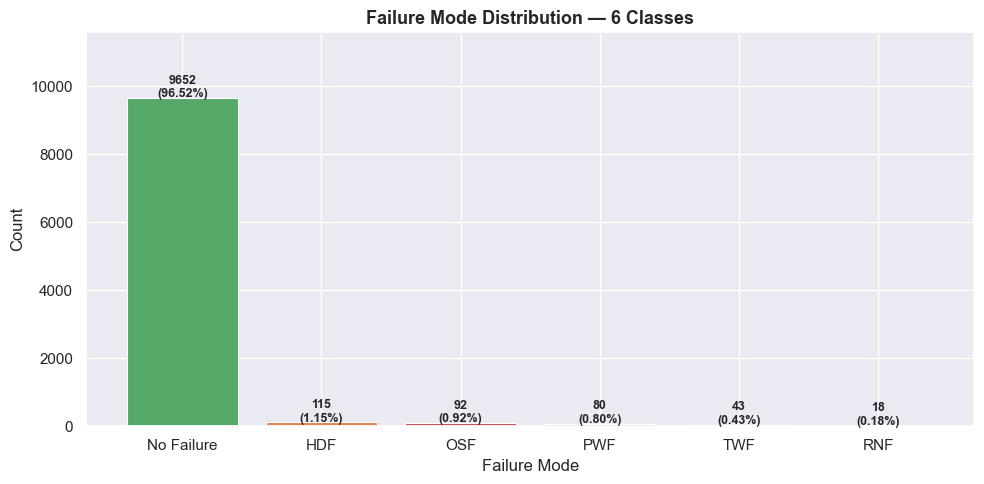

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))

mode_counts = df['failure_mode'].value_counts()
colors      = ['#55A868', '#DD8452', '#C44E52', '#4C72B0', '#9467BD', '#8C564B']

bars = ax.bar(
    mode_counts.index,
    mode_counts.values,
    color     = colors[:len(mode_counts)],
    edgecolor = 'white',
    linewidth = 0.8
)

for bar, count in zip(bars, mode_counts.values):
    pct = count / len(df) * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f'{count}\n({pct:.2f}%)',
        ha='center', fontsize=9, fontweight='bold'
    )

ax.set_title('Failure Mode Distribution — 6 Classes',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Failure Mode')
ax.set_ylabel('Count')
ax.set_ylim(0, mode_counts.max() * 1.2)
plt.tight_layout()
plt.savefig('../notebooks/failure_mode_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


Final feature selection

In [20]:
#features going in both models
feature_columns=[
    'air_temperature',
    'process_temperature',
    'rotational_speed',
    'torque',
    'tool_wear',
    'temp_diff',
    'power',
    'tool_wear_torque',
    'type_encoded'
]

#regression target
rul_target='rul'
#classification target
class_target='failure_mode_encoded'

print("Final feature set: ")
for i,col in enumerate(feature_columns,1):
    print(f" {i}. {col}")

print(f"\nRegression target: {rul_target}")
print(f"Classification target: {class_target}")
print(f"\n Total features: {len(feature_columns)}")

Final feature set: 
 1. air_temperature
 2. process_temperature
 3. rotational_speed
 4. torque
 5. tool_wear
 6. temp_diff
 7. power
 8. tool_wear_torque
 9. type_encoded

Regression target: rul
Classification target: failure_mode_encoded

 Total features: 9


Final clean DataFrame

In [21]:
keep_columns=feature_columns + [rul_target, class_target, 'failure_mode','machine_failure']
df_final=df[keep_columns].copy()
print("Final DataFrame built")
print(f"\n Shape: {df_final.shape}")
print(f"\n Columns: ")
for col in df_final.columns:
    print(f" - {col:<30} dtype: {df_final[col].dtype}")

Final DataFrame built

 Shape: (10000, 13)

 Columns: 
 - air_temperature                dtype: float64
 - process_temperature            dtype: float64
 - rotational_speed               dtype: int64
 - torque                         dtype: float64
 - tool_wear                      dtype: int64
 - temp_diff                      dtype: float64
 - power                          dtype: float64
 - tool_wear_torque               dtype: float64
 - type_encoded                   dtype: int64
 - rul                            dtype: int64
 - failure_mode_encoded           dtype: int64
 - failure_mode                   dtype: object
 - machine_failure                dtype: int64


Final quality checks

In [22]:
print("Final DataFrame Quality Check")

#check null
null_count = df_final.isnull().sum().sum()
print(f"\n 1. Total null values in final DataFrame: {null_count}")
if null_count == 0:
    print("No null values found - DataFrame is clean and ready for modeling")

#check duplicates
dup_count=df_final.duplicated().sum()
print(f"2. Duplicate rows: {dup_count}")
if dup_count==0:
    print("No duplicate records found - DataFrame is clean and ready for modeling")

#RUL range
rul_min=df_final['rul'].min()
rul_max=df_final['rul'].max()
print(f"\n 3. RUL range: {rul_min} to {rul_max}")

#failure mode classes
n_classes=df_final['failure_mode_encoded'].nunique()
print(f"\n 4. Failure mode classes: {n_classes} unique classes")

#type encoded values
type_vals=sorted(df_final['type_encoded'].unique().tolist())
print(f"\n 5. Type encoded values: {type_vals} (should be [0,1,2])")

#no negative power or tool_wear_torque values
neg_power=(df_final['power']<0).sum()
print(f"\n 6. Negative power values: {neg_power}")

print("all checks passed" if all([
    null_count == 0,
    rul_min >= 0,
    rul_max <= 240,
    n_classes == 6,
    type_vals == [0, 1, 2],
    neg_power == 0
])else "some checks failed - review outputs above")


Final DataFrame Quality Check

 1. Total null values in final DataFrame: 0
No null values found - DataFrame is clean and ready for modeling
2. Duplicate rows: 0
No duplicate records found - DataFrame is clean and ready for modeling

 3. RUL range: 0 to 240

 4. Failure mode classes: 6 unique classes

 5. Type encoded values: [0, 1, 2] (should be [0,1,2])

 6. Negative power values: 0
all checks passed


Saving engineered dataframe to csv

In [23]:
import os

# Save to data folder
output_path = os.path.join(project_root, 'data', 'engineered_data.csv')

df_final.to_csv(output_path, index=False)

print(f"   Engineered DataFrame saved")
print(f"   Path  : {output_path}")
print(f"   Shape : {df_final.shape}")
print(f"   Size  : {os.path.getsize(output_path) / 1024:.1f} KB")

   Engineered DataFrame saved
   Path  : c:\Users\aryap\Desktop\predictive_maintenance\data\engineered_data.csv
   Shape : (10000, 13)
   Size  : 882.0 KB


Final Preview

In [24]:
print("First 5 rows of final engineered DataFrame:\n")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
print(df_final.head())

print(f"\nSummary statistics of engineered features:\n")
print(df_final[feature_columns].describe().round(3).T)

First 5 rows of final engineered DataFrame:

   air_temperature  process_temperature  rotational_speed  torque  tool_wear  temp_diff        power  \
0            298.1                308.6              1551    42.8          0       10.5  6951.590560   
1            298.2                308.7              1408    46.3          3       10.5  6826.722724   
2            298.1                308.5              1498    49.4          5       10.4  7749.387543   
3            298.2                308.6              1433    39.5          7       10.4  5927.504659   
4            298.2                308.7              1408    40.0          9       10.5  5897.816608   

   tool_wear_torque  type_encoded  rul  failure_mode_encoded failure_mode  machine_failure  
0               0.0             1  240                     0   No Failure                0  
1             138.9             0  237                     0   No Failure                0  
2             247.0             0  235             